## Project Name: Shipment Price Prediction __ Linear Regression 

## 1) Problem statement.

- Our work for a company that sells sculptures that are acquired from various artists around the world. our task is to predict the cost required to ship these sculptures to customers based on the information provided in the dataset.

### 2)  Import Data

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Import the CSV Data as Pandas DataFrame**

In [4]:
# load Data
df = pd.read_csv("train.csv")


**Show Top 5 Records**

In [5]:
df.head()

,Customer Id,Artist Name,Artist Reputation,Height,Width,Weight,Material,Price Of Sculpture,Base Shipping Price,International,Express Shipment,Installation Included,Transport,Fragile,Customer Information,Remote Location,Scheduled Date,Delivery Date,Customer Location,Cost
0,fffe3900350033003300,Billy Jenkins,0.26,17.0,6.0,4128.0,Brass,13.91,16.27,Yes,Yes,No,Airways,No,Working Class,No,06/07/15,06/03/15,"New Michelle, OH 50777",-283.29
1,fffe3800330031003900,Jean Bryant,0.28,3.0,3.0,61.0,Brass,6.83,15.00,No,No,No,Roadways,No,Working Class,No,03/06/17,03/05/17,"New Michaelport, WY 12072",-159.96
2,fffe3600370035003100,Laura Miller,0.07,8.0,5.0,237.0,Clay,4.96,21.18,No,No,No,Roadways,Yes,Working Class,Yes,03/09/15,03/08/15,"Bowmanshire, WA 19241",-154.29
3,fffe350031003300,Robert Chaires,0.12,9.0,NaN,NaN,Aluminium,5.81,16.31,No,No,No,NaN,No,Wealthy,Yes,05/24/15,05/20/15,"East Robyn, KY 86375",-161.16
4,fffe3900320038003400,Rosalyn Krol,0.15,17.0,6.0,324.0,Aluminium,3.18,11.94,Yes,Yes,Yes,Airways,No,Working Class,No,12/18/16,12/14/16,"Aprilside, PA 52793",-159.23


**Shape of the dataset**

In [6]:
# shape
df.shape

(6500, 20)

**Summary of the dataset**

In [7]:
# Display summary statistics for a dataframe
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Artist Reputation,5750.0,0.461850,2.657811e-01,0.00,0.24,0.450,0.680,1.000000e+00
Height,6125.0,21.766204,1.196819e+01,3.00,12.00,20.000,30.000,7.300000e+01
Width,5916.0,9.617647,5.417000e+00,2.00,6.00,8.000,12.000,5.000000e+01
Weight,5913.0,400694.821918,2.678081e+06,3.00,503.00,3102.000,36456.000,1.179279e+08
Price Of Sculpture,6500.0,1192.420090,8.819617e+03,3.00,5.23,8.025,89.470,3.823857e+05
Base Shipping Price,6500.0,37.407174,2.687352e+01,10.00,16.70,23.505,57.905,9.998000e+01
Cost,6500.0,17139.195668,2.406579e+05,-880172.65,188.44,382.065,1156.115,1.114343e+07


### Statistical Inferences
- Median Cost Of Shipping Sculpture is 17139.
- 25% of the population is Cost Of Sculpture below 188
- Average Artist Reputation of the population is 0.46

* The difference between 75th percentile and Max also suggests the skewness

* We can confirm the insights we got from data distribution, as skewness is more for Height, Width, and Base Shipping Price, and skewness of Weight, Price of Sculpture because of Outliers

**Check Datatypes in the dataset**

In [9]:
# Data Type
df.dtypes

Customer Id               object
Artist Name               object
Artist Reputation        float64
Height                   float64
Width                    float64
Weight                   float64
Material                  object
Price Of Sculpture       float64
Base Shipping Price      float64
International             object
Express Shipment          object
Installation Included     object
Transport                 object
Fragile                   object
Customer Information      object
Remote Location           object
Scheduled Date            object
Delivery Date             object
Customer Location         object
Cost                     float64
dtype: object

## 3. EXPLORING DATA

**Most of the features seems to be of object data type, Now let's seperate Categorical and numerical columns**

In [10]:
# target column
target_feature = 'Cost'

In [11]:
# Seperate Numerical and Categorical Columns

# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))


We have 7 numerical features : ['Artist Reputation', 'Height', 'Width', 'Weight', 'Price Of Sculpture', 'Base Shipping Price', 'Cost']

We have 13 categorical features : ['Customer Id', 'Artist Name', 'Material', 'International', 'Express Shipment', 'Installation Included', 'Transport', 'Fragile', 'Customer Information', 'Remote Location', 'Scheduled Date', 'Delivery Date', 'Customer Location']


## Univariate Analysis

**The term univariate analysis refers to the analysis of one variable prefix “uni” means “one.” The purpose of univariate analysis is to understand the distribution of values for a single variable.**

### 1. Numerical Features

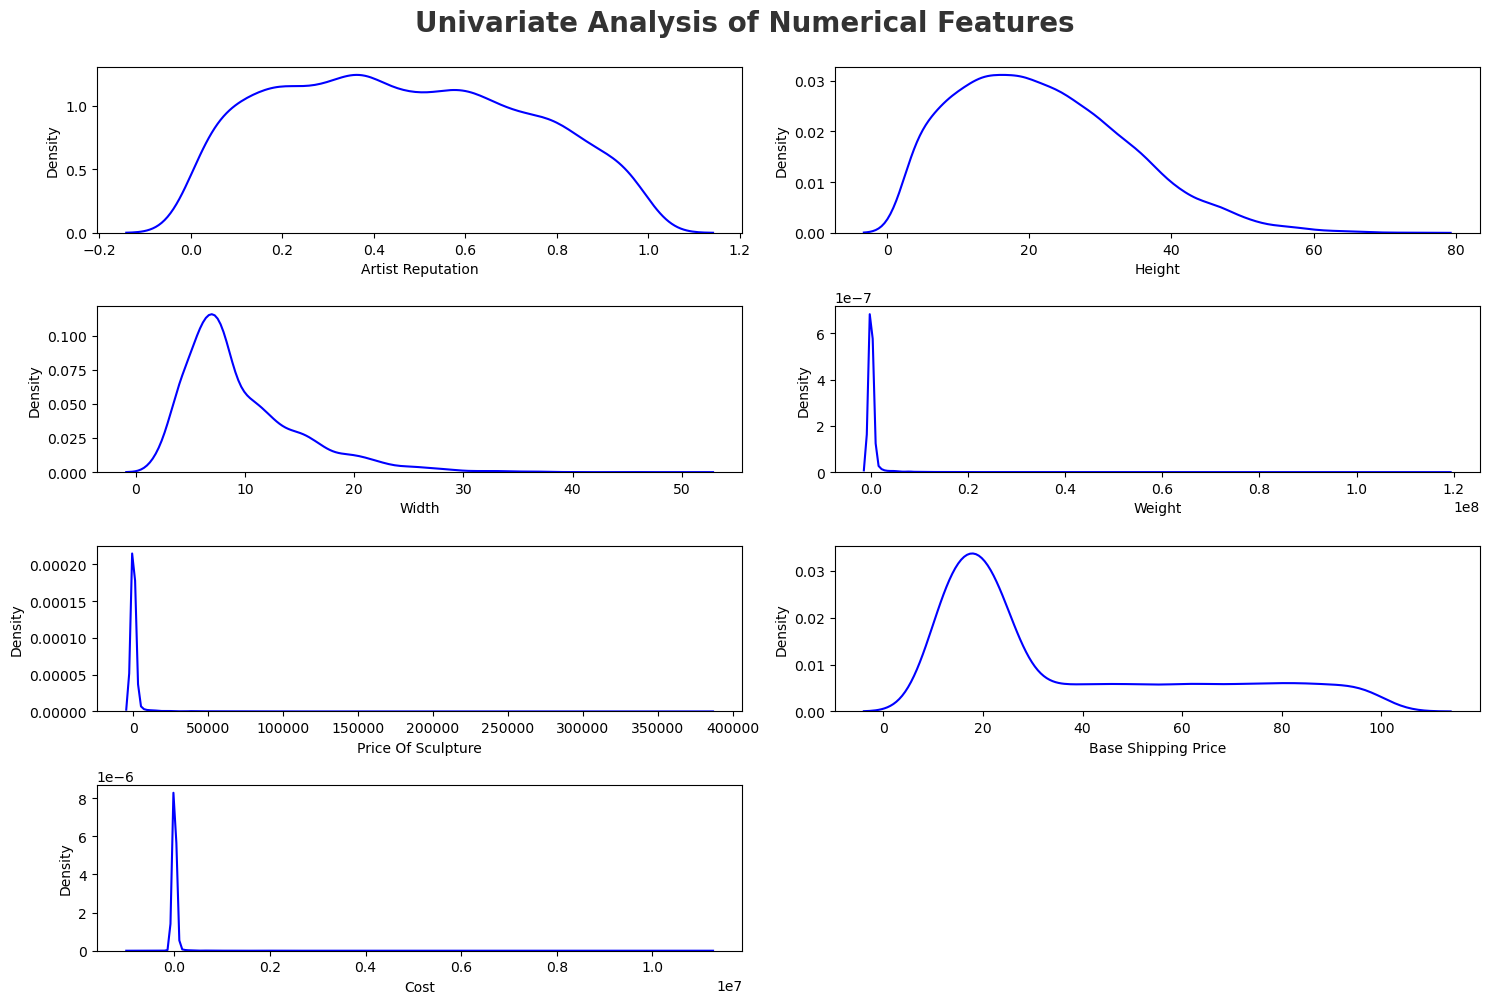

In [14]:
# Numerical Feature Distribution -- kdeplot
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(4, 2, i+1)
    sns.kdeplot(x=df[numeric_features[i]], color='blue')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

<font size=3>**Report**</font>

* <font size=3> `Height`, `Width` and `Base Shipping price` are positively skewed</font>

* <font size=3>`Weight`, `Price of Sculpture` has many outliers</font>

### Categorical Features

In [17]:
# Categorcial Features Statistical Distribution
df.describe(include='object').T

,count,unique,top,freq
Customer Id,6500,6500,fffe3700310031003600,1
Artist Name,6500,6449,John Brown,4
Material,5736,7,Brass,847
International,6500,2,No,4294
Express Shipment,6500,2,No,4365
Installation Included,6500,2,No,3916
Transport,5108,3,Roadways,2064
Fragile,6500,2,No,5461
Customer Information,6500,2,Working Class,4803
Remote Location,5729,2,No,4594


In [18]:
# Unique Values of Categorical Columns
categorical_columns = []
for i in categorical_features:
    print(f'{i}: {len(df[i].unique())}')
    if len(df[i].unique()) < 10:
        categorical_columns.append(i)


Customer Id: 6500
Artist Name: 6449
Material: 8
International: 2
Express Shipment: 2
Installation Included: 2
Transport: 4
Fragile: 2
Customer Information: 2
Remote Location: 3
Scheduled Date: 1660
Delivery Date: 1664
Customer Location: 6500


- Key Insight
* `Customer Id`, `Artist Name`, `Customer location` have 6500 unique values, so they can be dropped.
    - Becuase when we Perfome One hot encoding then it's became large number of features.

* `Scheduled date` and `Delivery date` needs feature engineering
    - Because we only need Year and month (Not needed of day)
    - It is convert into time features

In [21]:
# After Remove and not consider TimeDate column then __ See the Categorical Columns
categorical_columns

['Material',
 'International',
 'Express Shipment',
 'Installation Included',
 'Transport',
 'Fragile',
 'Customer Information',
 'Remote Location']

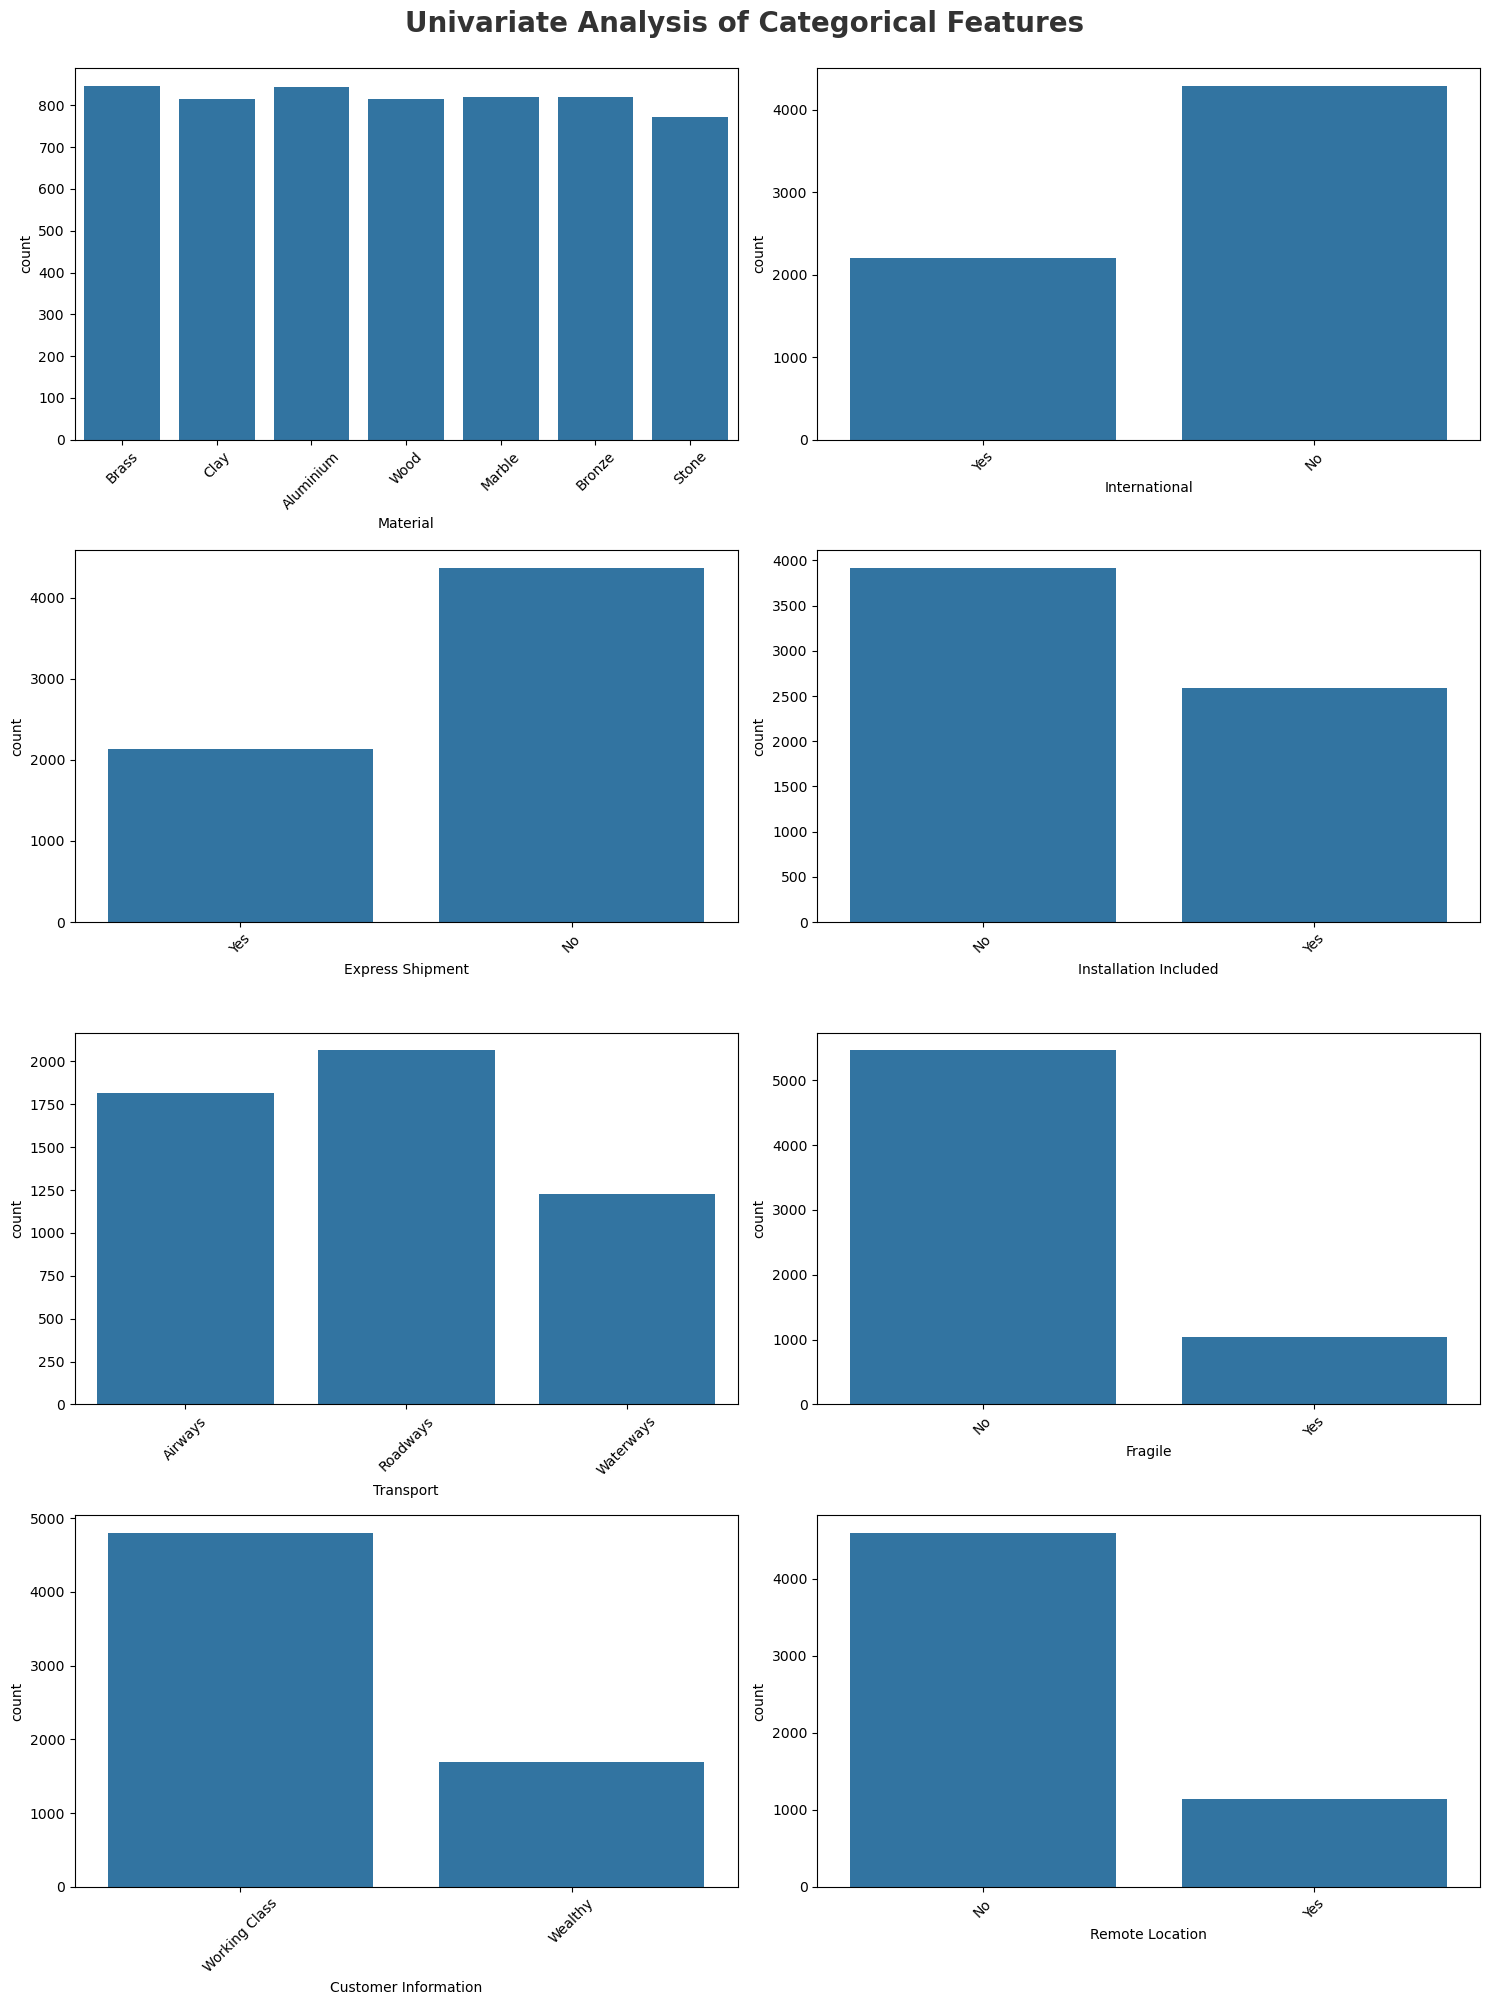

In [22]:
# categorical columns
plt.figure(figsize=(15, 20))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
for i in range(0, len(categorical_columns)):
    plt.subplot(4, 2, i+1)
    sns.countplot(x=df[categorical_columns[i]])
    plt.xlabel(categorical_columns[i])
    plt.xticks(rotation=45)
    plt.tight_layout()

**Insights**

* `Material column` has seven unique value, which are almost equally distributed</font>

* There are 6 bi-variate categorical columns</font>

<font size=5>**Checking the Null Values in dataset**</font>


In [23]:
# Null Value checking
df.isnull().sum()

Customer Id                 0
Artist Name                 0
Artist Reputation         750
Height                    375
Width                     584
Weight                    587
Material                  764
Price Of Sculpture          0
Base Shipping Price         0
International               0
Express Shipment            0
Installation Included       0
Transport                1392
Fragile                     0
Customer Information        0
Remote Location           771
Scheduled Date              0
Delivery Date               0
Customer Location           0
Cost                        0
dtype: int64

**Insights**

- There are 7 columns which has null values

## Multivariate Analysis
* Multivariate analysis is the analysis of more than one variable.

<font size=5>**Correlation in Numerical Features**</font>

In [31]:
# list of numerical features
numeric_features

['Artist Reputation',
 'Height',
 'Width',
 'Weight',
 'Price Of Sculpture',
 'Base Shipping Price',
 'Cost']

In [24]:
df[(list(df.columns)[1:])].corr(numeric_only=True)

,Artist Reputation,Height,Width,Weight,Price Of Sculpture,Base Shipping Price,Cost
Artist Reputation,1.000000,-0.000513,-0.009203,0.017113,0.054286,-0.011820,0.067368
Height,-0.000513,1.000000,0.768376,0.226543,0.200942,0.353858,0.106047
Width,-0.009203,0.768376,1.000000,0.329603,0.293544,0.332361,0.158159
Weight,0.017113,0.226543,0.329603,1.000000,0.890205,0.150856,0.417263
Price Of Sculpture,0.054286,0.200942,0.293544,0.890205,1.000000,0.134407,0.476231
Base Shipping Price,-0.011820,0.353858,0.332361,0.150856,0.134407,1.000000,0.053068
Cost,0.067368,0.106047,0.158159,0.417263,0.476231,0.053068,1.000000


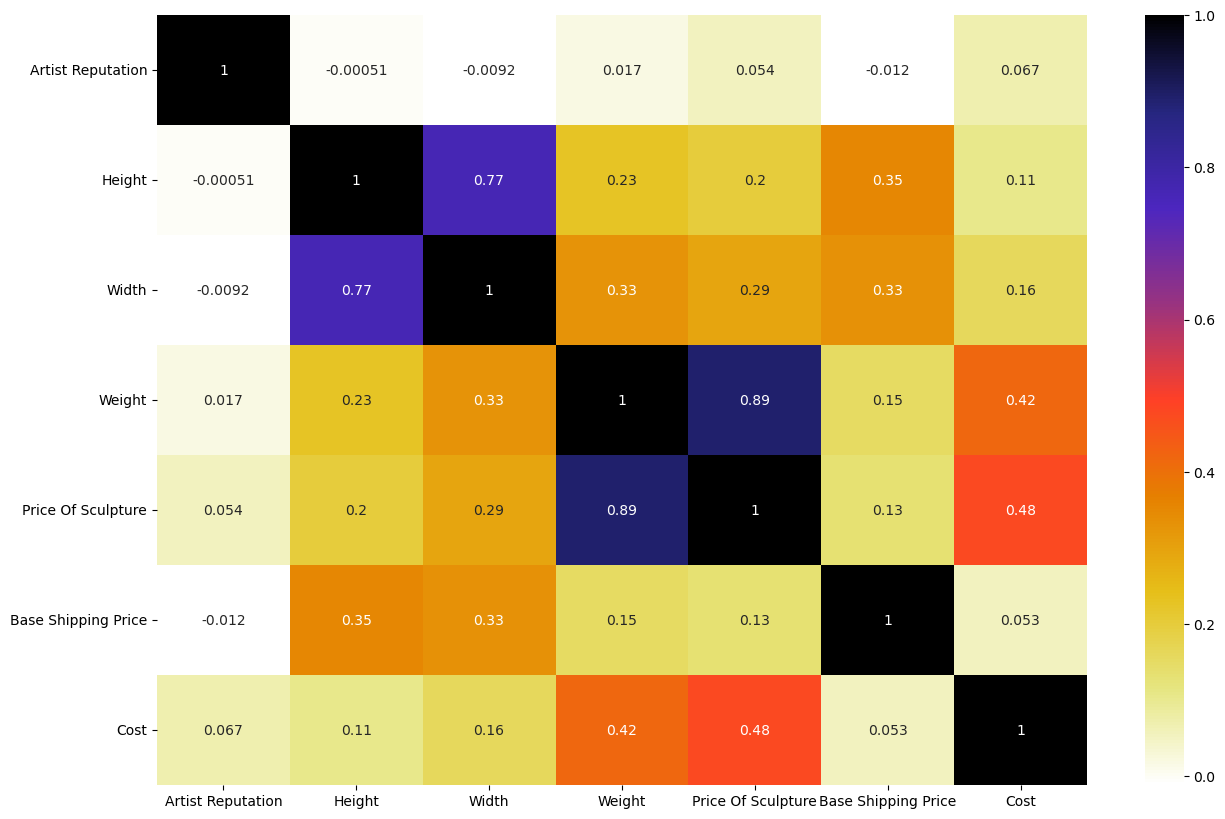

In [32]:
# heatmap
plt.figure(figsize = (15,10))
sns.heatmap(df.corr(numeric_only=True), cmap="CMRmap_r", annot=True)
plt.show()

**Insights**
- There is a high correlation between `Height`-`Width`, and `Weight`-`Price of Sculpture`


### Relationship between target and numerical columns

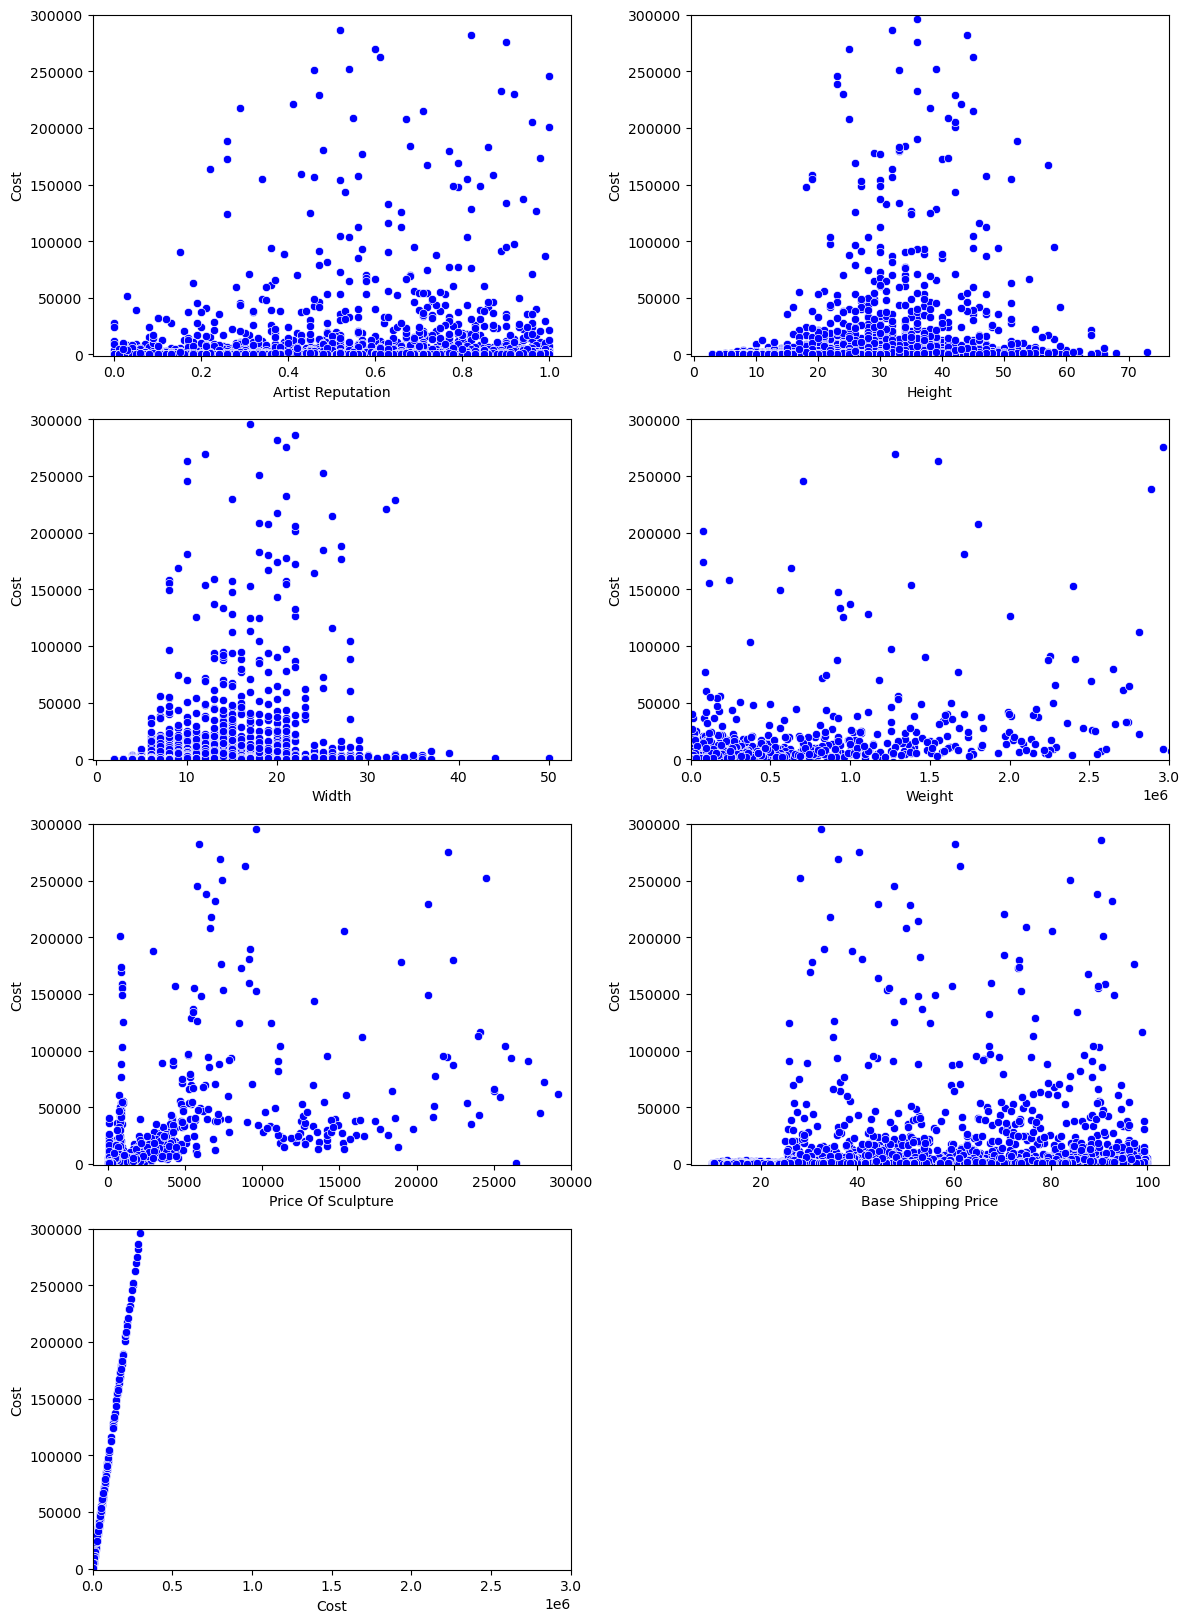

In [33]:
### Relationship between target and numerical columns

fig = plt.figure(figsize=(12, 24))

for i in range(0, len(numeric_features)):
    ax = plt.subplot(6, 2, i+1)
    sns.scatterplot(data= df ,y=target_feature, x=numeric_features[i], color='b')
    if df[numeric_features[i]].max() > 30000:
        plt.xlim(-1000,30000)
    if df[numeric_features[i]].max() > 3000000:
        plt.xlim(-1000,3000000)
    plt.ylim(-1000, 300000)
    plt.tight_layout()


**Insights**

- We can observe that there seems to be very low linear relationship between the independent and dependent features

- There seems to be linear relationship between Price of sculpture and the target column

**Model Selection: non-linear model is best choice of this dataset**

## Visualizing Independent columns

In [39]:
df.head(2)

,Customer Id,Artist Name,Artist Reputation,Height,Width,Weight,Material,Price Of Sculpture,Base Shipping Price,International,Express Shipment,Installation Included,Transport,Fragile,Customer Information,Remote Location,Scheduled Date,Delivery Date,Customer Location,Cost
0,fffe3900350033003300,Billy Jenkins,0.26,17.0,6.0,4128.0,Brass,13.91,16.27,Yes,Yes,No,Airways,No,Working Class,No,06/07/15,06/03/15,"New Michelle, OH 50777",-283.29
1,fffe3800330031003900,Jean Bryant,0.28,3.0,3.0,61.0,Brass,6.83,15.00,No,No,No,Roadways,No,Working Class,No,03/06/17,03/05/17,"New Michaelport, WY 12072",-159.96


<font size=5>**Target Feature**</font>


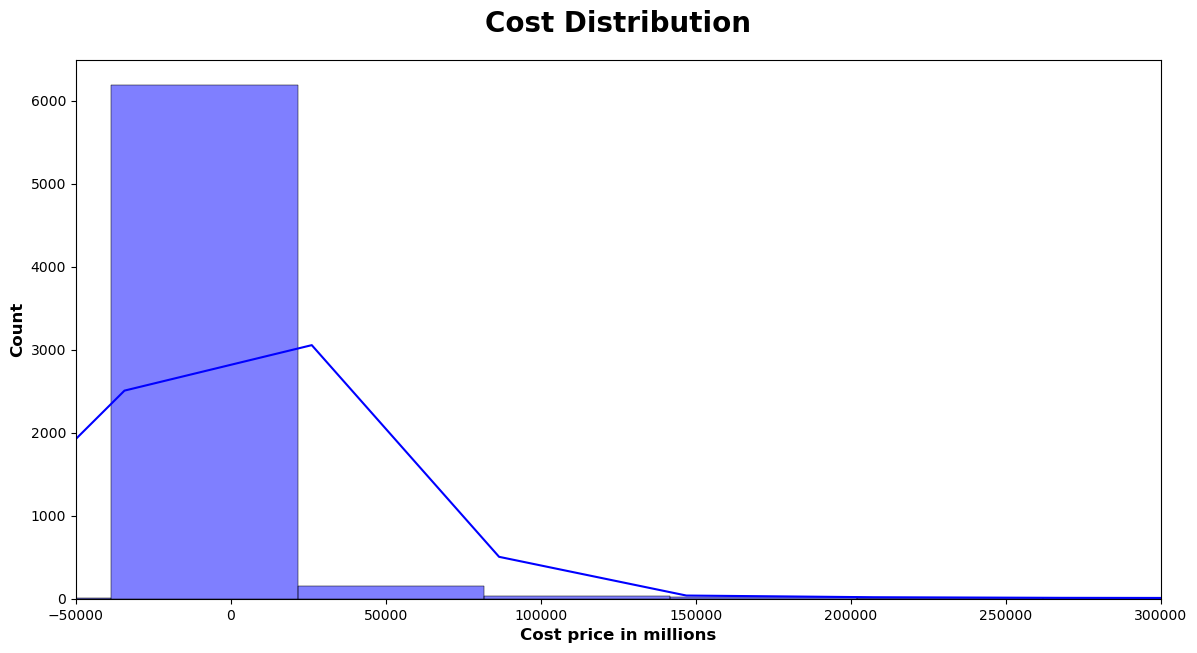

In [34]:
plt.subplots(figsize=(14,7))
sns.histplot(df[target_feature], bins=200, kde=True, color = 'b')
plt.title("Cost Distribution", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Cost price in millions", weight="bold", fontsize=12)
plt.xlim(-50000,300000)
plt.show()

(-50000.0, 300000.0)

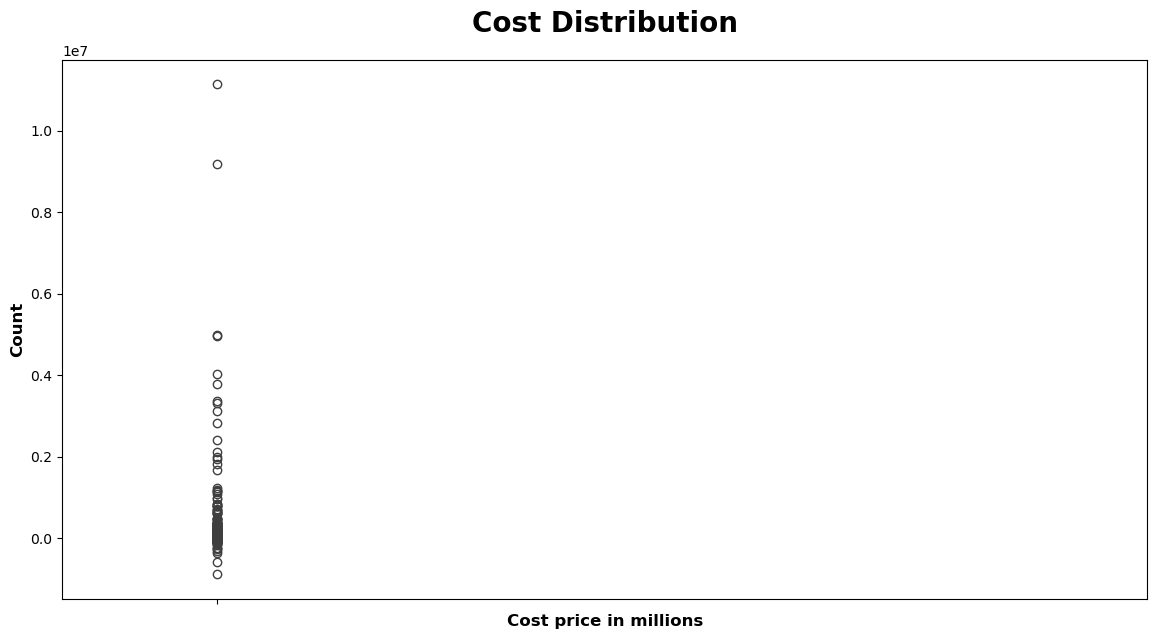

In [37]:
# To see the outlier in the target feature
plt.subplots(figsize=(14,7))
sns.boxplot(df[target_feature])
plt.title("Cost Distribution", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Cost price in millions", weight="bold", fontsize=12)
plt.xlim(-50000,300000)

**Insights**

- There are outliers in the target feature and we need to transform

In [38]:
df.head(2)

,Customer Id,Artist Name,Artist Reputation,Height,Width,Weight,Material,Price Of Sculpture,Base Shipping Price,International,Express Shipment,Installation Included,Transport,Fragile,Customer Information,Remote Location,Scheduled Date,Delivery Date,Customer Location,Cost
0,fffe3900350033003300,Billy Jenkins,0.26,17.0,6.0,4128.0,Brass,13.91,16.27,Yes,Yes,No,Airways,No,Working Class,No,06/07/15,06/03/15,"New Michelle, OH 50777",-283.29
1,fffe3800330031003900,Jean Bryant,0.28,3.0,3.0,61.0,Brass,6.83,15.00,No,No,No,Roadways,No,Working Class,No,03/06/17,03/05/17,"New Michaelport, WY 12072",-159.96


<font size=5>**How shipment type is affecting cost of shipment?**</font>

C:\Users\kz\AppData\Local\Temp\ipykernel_22408\3347680163.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=international.index, y=international.values, ec = "black", palette="Set2")


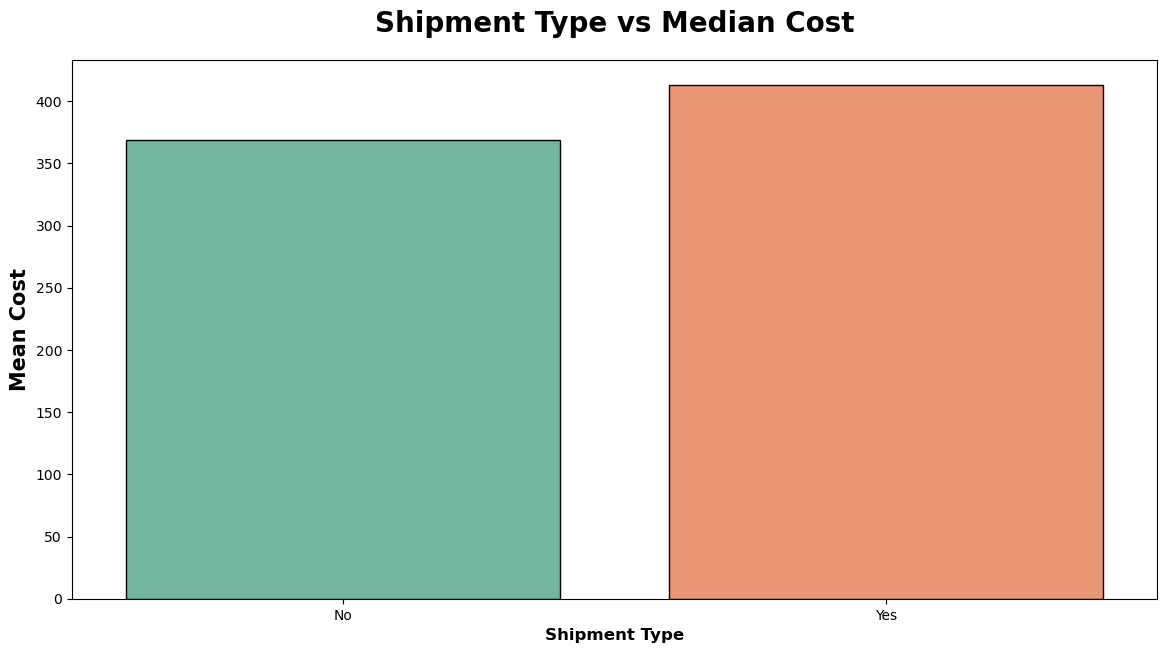

In [40]:
international = df.groupby('International')[target_feature].median()
international.to_frame()

plt.subplots(figsize=(14,7))
sns.barplot(x=international.index, y=international.values, ec = "black", palette="Set2")
plt.title("Shipment Type vs Median Cost", weight="bold",fontsize=20, pad=20)
plt.ylabel("Mean Cost", weight="bold", fontsize=15)
plt.xlabel("Shipment Type", weight="bold", fontsize=12)
plt.show()

In [41]:
df['International'].value_counts()

International
No     4294
Yes    2206
Name: count, dtype: int64

In [42]:
international_shipment_median = df[df['International'] == 'Yes']['Cost'].median()
domestic_shipment_median = df[df['International'] == 'No']['Cost'].median()

print(f"The difference between the median shipment price of International and domestic is {international_shipment_median-domestic_shipment_median}")

The difference between the median shipment price of International and domestic is 43.91500000000008


**Insights**

- There is only a difference of 43 in the shipping cost between International and domestic, so it won't affect much at the prediction

- There are much more domestic shipement than international

<font size=5>**How Express Shipment is affecting cost of shipment?**</font>

C:\Users\kz\AppData\Local\Temp\ipykernel_22408\2741062562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=express_ship.index, y=express_ship.values, ec = "black", palette="Set1")


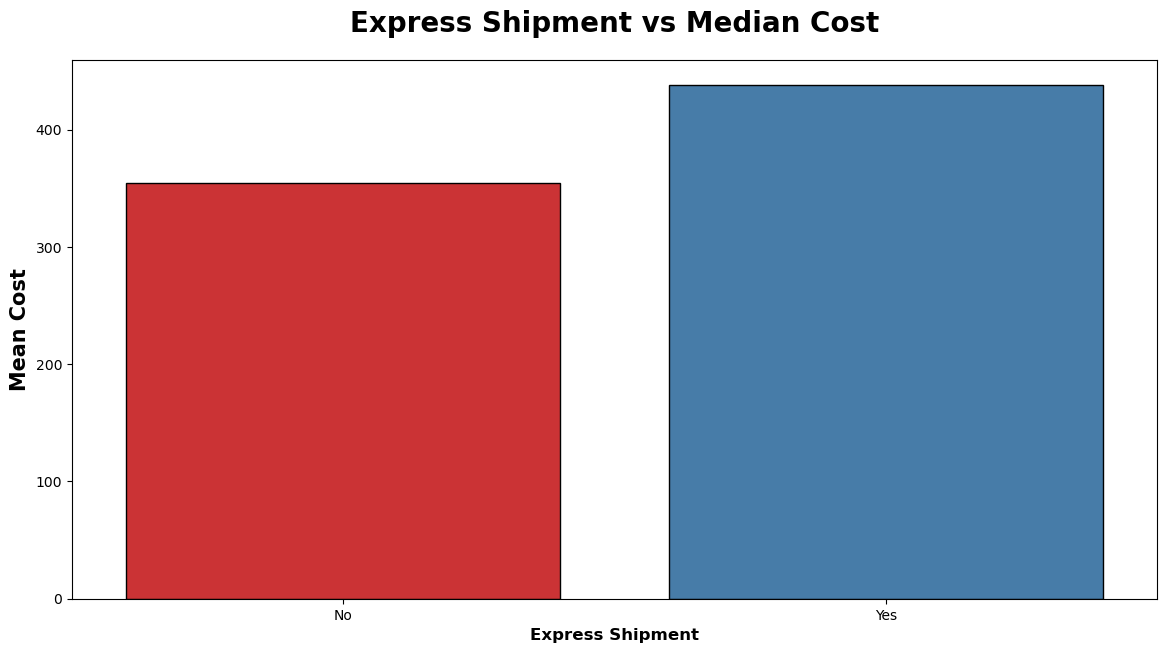

In [43]:
express_ship = df.groupby('Express Shipment')[target_feature].median()
express_ship.to_frame()

plt.subplots(figsize=(14,7))
sns.barplot(x=express_ship.index, y=express_ship.values, ec = "black", palette="Set1")
plt.title("Express Shipment vs Median Cost", weight="bold",fontsize=20, pad=20)
plt.ylabel("Mean Cost", weight="bold", fontsize=15)
plt.xlabel("Express Shipment", weight="bold", fontsize=12)
plt.show()

In [44]:
df['Express Shipment'].value_counts()

Express Shipment
No     4365
Yes    2135
Name: count, dtype: int64

## Visualizing date columns


In [45]:
# Convert the type of Schedule Data and Delivery Data feature to datetime 
df['Scheduled Date'] = pd.to_datetime(df['Scheduled Date'])
df['Delivery Date'] = pd.to_datetime(df['Delivery Date'])

C:\Users\kz\AppData\Local\Temp\ipykernel_22408\2061010854.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Scheduled Date'] = pd.to_datetime(df['Scheduled Date'])
C:\Users\kz\AppData\Local\Temp\ipykernel_22408\2061010854.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Delivery Date'] = pd.to_datetime(df['Delivery Date'])


In [ ]:
# only extract the Year and month from Scheduled Date and add to the origional columns
df['year'] = pd.DatetimeIndex(df['Scheduled Date']).year
df['month'] = pd.DatetimeIndex(df['Scheduled Date']).month

In [48]:
df.head(2)

,Customer Id,Artist Name,Artist Reputation,Height,Width,Weight,Material,Price Of Sculpture,Base Shipping Price,International,...,Transport,Fragile,Customer Information,Remote Location,Scheduled Date,Delivery Date,Customer Location,Cost,year,month
0,fffe3900350033003300,Billy Jenkins,0.26,17.0,6.0,4128.0,Brass,13.91,16.27,Yes,...,Airways,No,Working Class,No,2015-06-07,2015-06-03,"New Michelle, OH 50777",-283.29,2015,6
1,fffe3800330031003900,Jean Bryant,0.28,3.0,3.0,61.0,Brass,6.83,15.00,No,...,Roadways,No,Working Class,No,2017-03-06,2017-03-05,"New Michaelport, WY 12072",-159.96,2017,3


<font size=5>**How year and month affecting cost of shipment?**</font>

In [49]:
# the mean Cost (target) of each and year vs month
x = df.groupby(["year", "month"])["Cost"].mean()
df_wide = x.unstack().T
df_wide.head()

year,2015,2016,2017,2018,2019
month,,,,,
1,1243.620800,12930.272703,13388.419779,47457.768519,2430.550495
2,34249.351818,10034.132545,3427.163673,6612.238687,3840.484630
3,23775.741185,10757.195810,41359.835804,20026.385455,2265.834019
4,94668.648276,4288.732696,26634.491452,4138.730309,8374.422975
5,15884.313833,4103.283514,8857.153077,17461.434118,14129.902741


In [50]:
# To Specific month
df_wide[2015]

month
1      1243.620800
2     34249.351818
3     23775.741185
4     94668.648276
5     15884.313833
6      4480.208318
7      1426.520159
8     17085.121760
9      4258.188871
10     4979.386768
11    53043.073800
12    40081.836509
Name: 2015, dtype: float64

<font size=5>**Visualize Representation: year and month affecting cost of shipment?**</font>

C:\Users\kz\AppData\Local\Temp\ipykernel_22408\1296080208.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=df_wide[i],x=df_wide.index,ec = "black", palette="Set2")


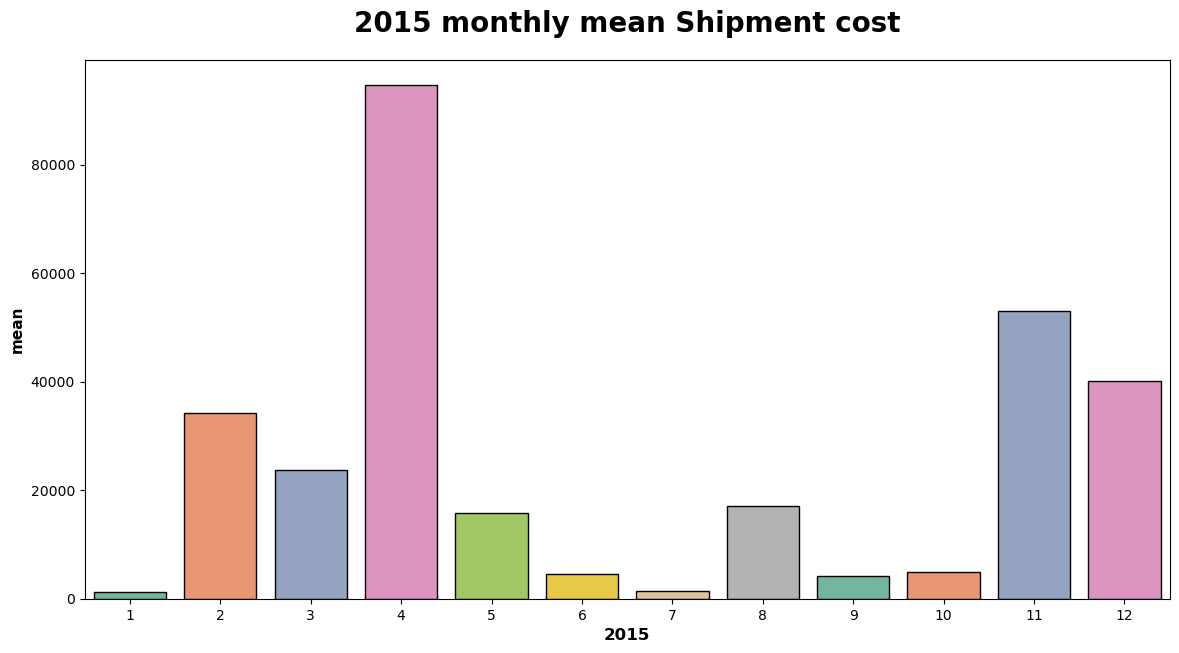

C:\Users\kz\AppData\Local\Temp\ipykernel_22408\1296080208.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=df_wide[i],x=df_wide.index,ec = "black", palette="Set2")


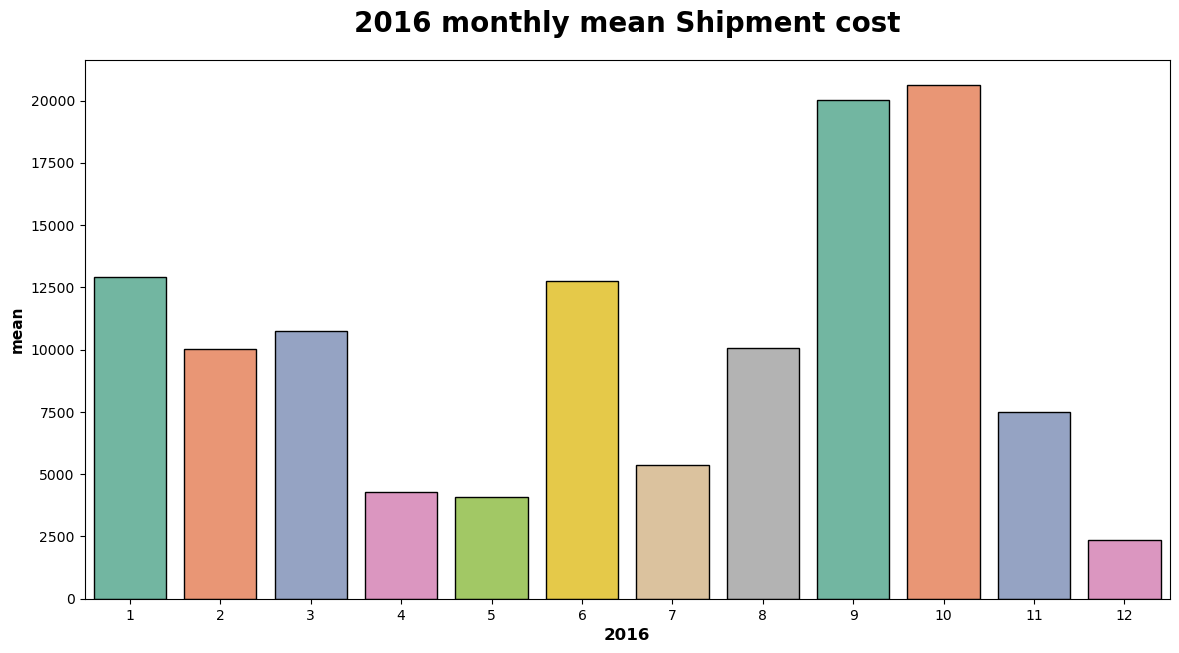

C:\Users\kz\AppData\Local\Temp\ipykernel_22408\1296080208.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=df_wide[i],x=df_wide.index,ec = "black", palette="Set2")


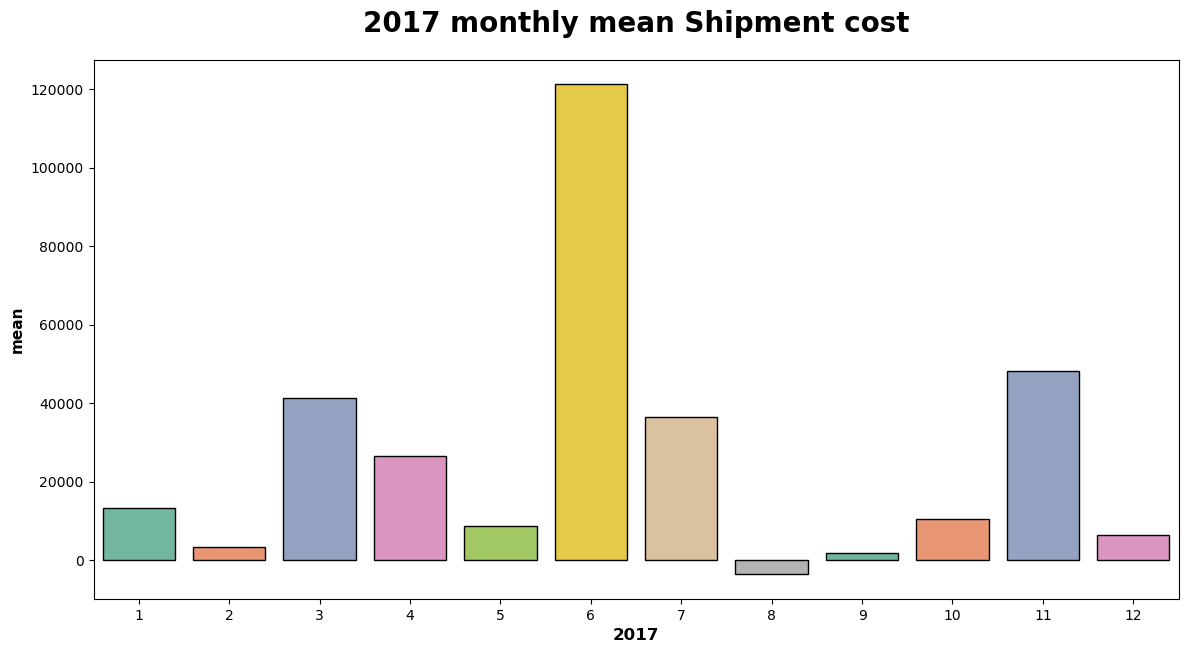

C:\Users\kz\AppData\Local\Temp\ipykernel_22408\1296080208.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=df_wide[i],x=df_wide.index,ec = "black", palette="Set2")


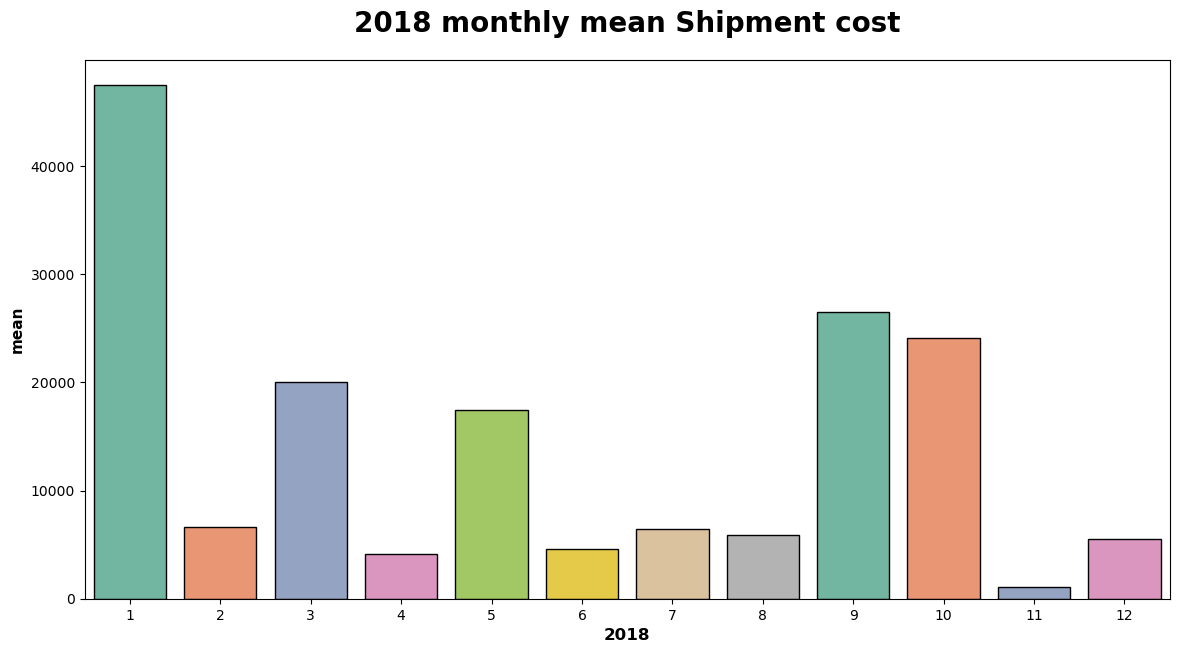

C:\Users\kz\AppData\Local\Temp\ipykernel_22408\1296080208.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=df_wide[i],x=df_wide.index,ec = "black", palette="Set2")


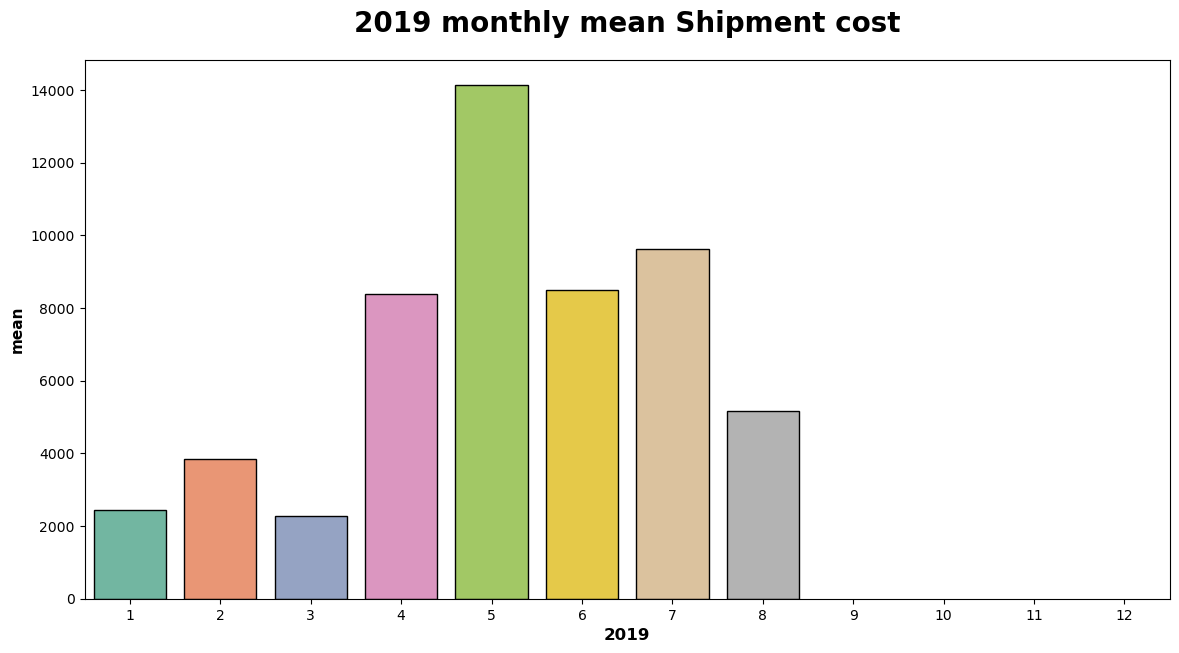

In [51]:
for i in df_wide.columns:
    plt.subplots(figsize=(14,7))
    sns.barplot(y=df_wide[i],x=df_wide.index,ec = "black", palette="Set2")
    plt.title(str(i) + " monthly mean Shipment cost", weight="bold",fontsize=20, pad=20)
    plt.ylabel("mean", weight="bold", fontsize=11)
    plt.xlabel(i, weight="bold", fontsize=12)
    plt.show()

**Insights**
 - Monthly distribution of every year is different
 - For 2015, 2016 and 2018 There were more cost at the start and end of the year.
 - For 2017 and 2019 cost were high mid year.

C:\Users\kz\AppData\Local\Temp\ipykernel_22408\3063941337.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df.year,ec = "black", palette="Set2")


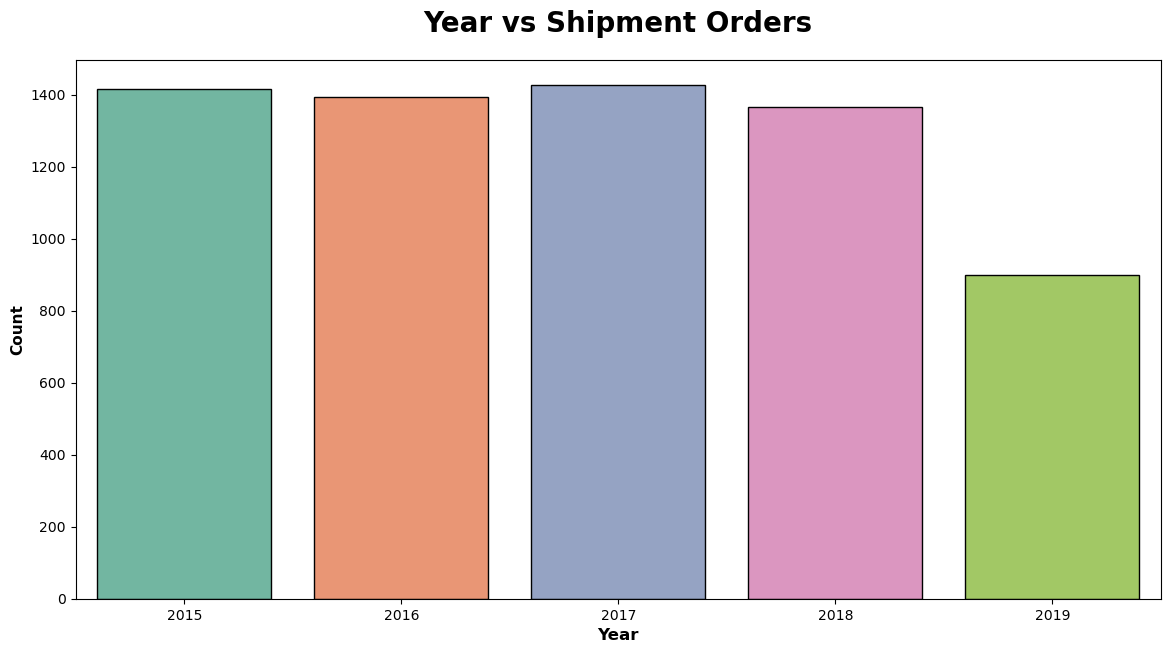

In [52]:
# Shipment order count base on Year
plt.subplots(figsize=(14,7))
sns.countplot(x=df.year,ec = "black", palette="Set2")
plt.title("Year vs Shipment Orders", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=11)
plt.xlabel("Year", weight="bold", fontsize=12)
plt.show()

C:\Users\kz\AppData\Local\Temp\ipykernel_22408\1846697422.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df.month,ec = "black", palette="Set2")


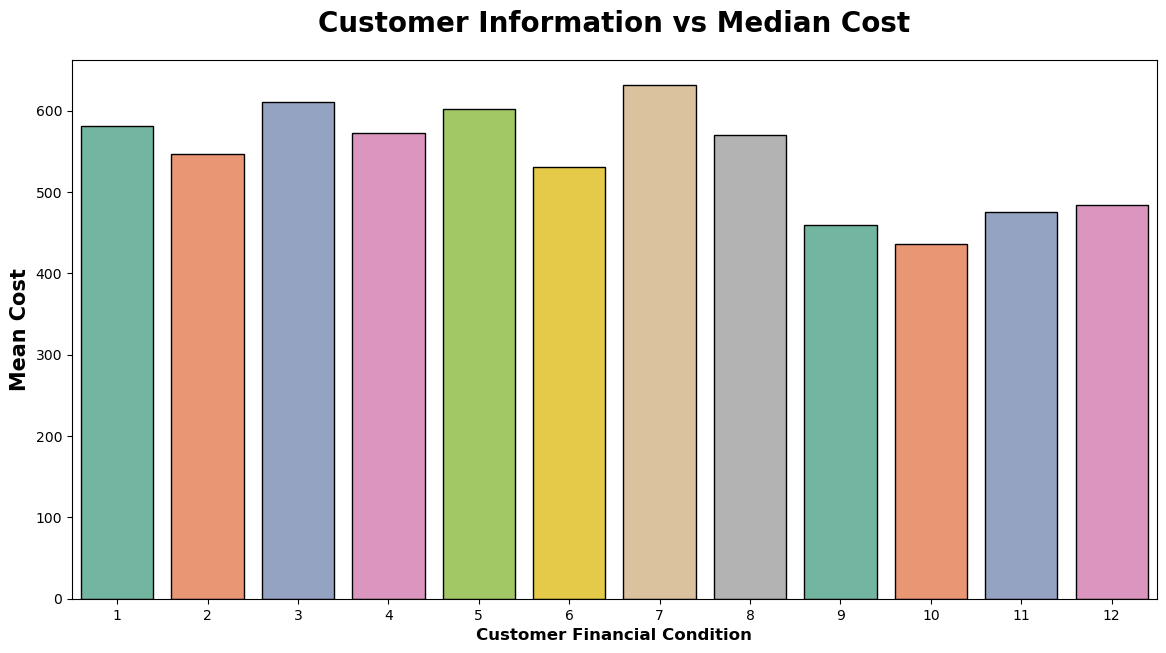

In [53]:
plt.subplots(figsize=(14,7))
sns.countplot(x=df.month,ec = "black", palette="Set2")
plt.title("Customer Information vs Median Cost", weight="bold",fontsize=20, pad=20)
plt.ylabel("Mean Cost", weight="bold", fontsize=15)
plt.xlabel("Customer Financial Condition", weight="bold", fontsize=12)
plt.show()

# Final Report


* The `Cost` column is the target to predict.
* The target variable here is continuous.
* There are outliers in some columns we have to remove outliers.
* `date` column should be configured to extract `year` and `month`.
* Null values in `Artist Reputation`, `Height`, `Width`, `Weight`, `Material`, `Transport`, `Remote Location` needs to be handled